# **Ejercicio 5 — Análisis exploratorio**

Se trabaja sobre `data/processed/tweets_procesado.csv`, columna `tokens`.

In [1]:
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

df = pd.read_csv("../data/processed/tweets_procesado.csv")
df["tokens"] = df["tokens"].fillna("")

conteo = {
    "desastre": Counter(w for s in df.loc[df["target"] == 1, "tokens"] for w in s.split()),
    "no_desastre": Counter(w for s in df.loc[df["target"] == 0, "tokens"] for w in s.split()),
}

print(f"tweets de desastre real : {(df['target'] == 1).sum():,}")
print(f"tweets que no lo son    : {(df['target'] == 0).sum():,}")

tweets de desastre real : 3,188
tweets que no lo son    : 4,297


## **1. Palabra que más se repite en cada categoría**

In [2]:
filas = []
for clase, c in conteo.items():
    total = sum(c.values())
    for palabra, f in c.most_common(10):
        filas.append({"clase": clase, "palabra": palabra, "frecuencia": f,
                      "pct_de_la_clase": round(f / total * 100, 3)})

top10 = pd.DataFrame(filas)
pd.concat([
    top10[top10["clase"] == "desastre"].reset_index(drop=True)[
        ["palabra", "frecuencia", "pct_de_la_clase"]].add_suffix("_desastre"),
    top10[top10["clase"] == "no_desastre"].reset_index(drop=True)[
        ["palabra", "frecuencia", "pct_de_la_clase"]].add_suffix("_no_desastre"),
], axis=1)

,palabra_desastre,frecuencia_desastre,pct_de_la_clase_desastre,palabra_no_desastre,frecuencia_no_desastre,pct_de_la_clase_no_desastre
0,fire,262,0.917,like,254,0.745
1,news,139,0.486,get,185,0.543
2,via,119,0.416,new,171,0.502
3,disaster,116,0.406,would,147,0.431
4,california,114,0.399,one,139,0.408
5,police,107,0.374,body,119,0.349
6,people,102,0.357,day,102,0.299
7,home,102,0.357,time,102,0.299
8,family,102,0.357,video,101,0.296
9,suicide,101,0.353,via,98,0.287


La palabra más repetida entre los tweets de desastre real es **`fire`**, con 262 apariciones, y
entre los que no lo son es **`like`**, con 254. Considero que el contraste resume bien el dataset,
ya que de un lado el término más común nombra un suceso y del otro es una muletilla de conversación.

Cabe mencionar que `fire` no es exclusiva de su clase, pues también aparece 88 veces del otro lado
por el uso figurado, y esto se retoma en el punto 4.

## **2. Nube de palabras**

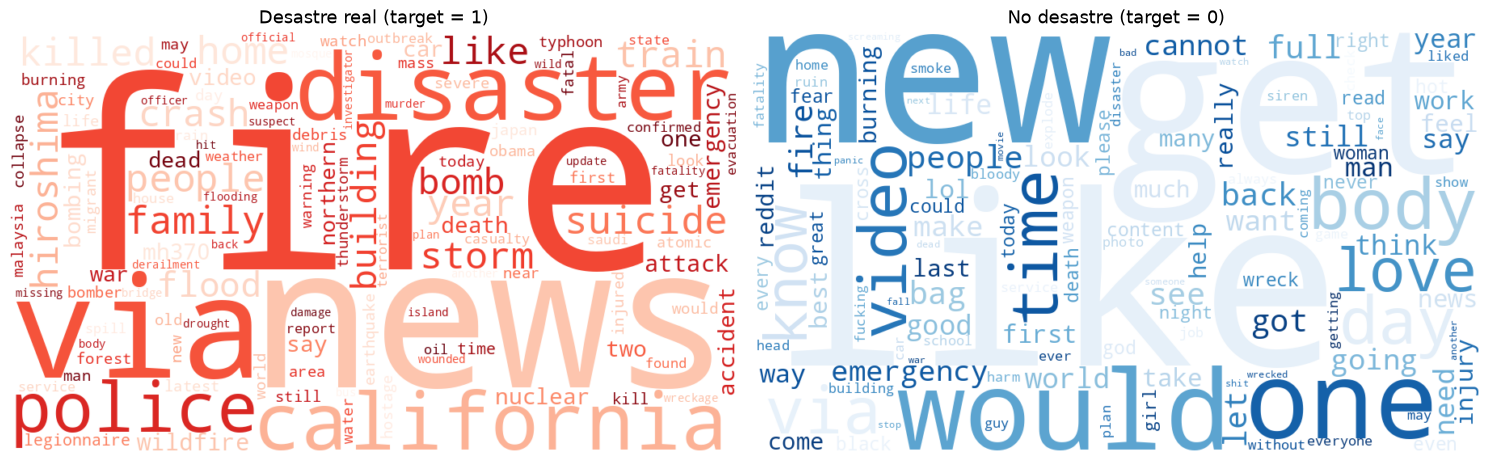

In [3]:
def nube(frecuencias, titulo, ax, mapa):
    wc = WordCloud(width=900, height=520, background_color="white",
                   colormap=mapa, max_words=120, random_state=42)
    ax.imshow(wc.generate_from_frequencies(frecuencias), interpolation="bilinear")
    ax.set_title(titulo, fontsize=13)
    ax.axis("off")


fig, axes = plt.subplots(1, 2, figsize=(15, 6))
nube(conteo["desastre"], "Desastre real (target = 1)", axes[0], "Reds")
nube(conteo["no_desastre"], "No desastre (target = 0)", axes[1], "Blues")
plt.tight_layout()
plt.show()

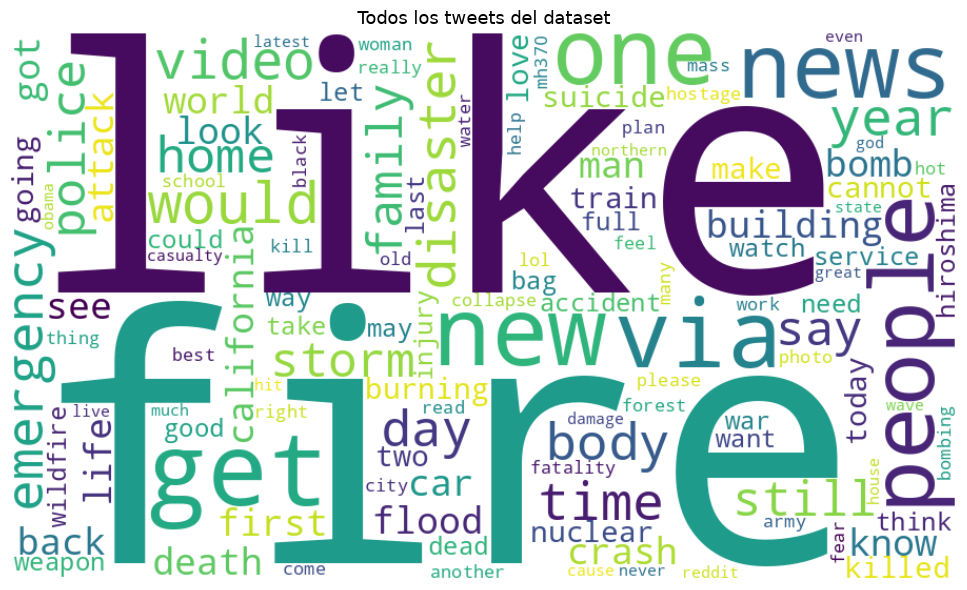

In [4]:
fig, ax = plt.subplots(figsize=(13, 6))
nube(conteo["desastre"] + conteo["no_desastre"], "Todos los tweets del dataset", ax, "viridis")
plt.tight_layout()
plt.show()

Las nubes separan los dos vocabularios a simple vista: del lado de desastre dominan `fire`, `news`,
`disaster`, `police`, `suicide` y `california`, mientras que del otro dominan `like`, `get`, `new`,
`would` y `body`. En la nube general se pierde esa distinción y quedan mezcladas las dos, o sea que
mirar el corpus completo sin separar por clase esconde justamente lo que interesa.

## **3. Histograma de las palabras que más se repiten**

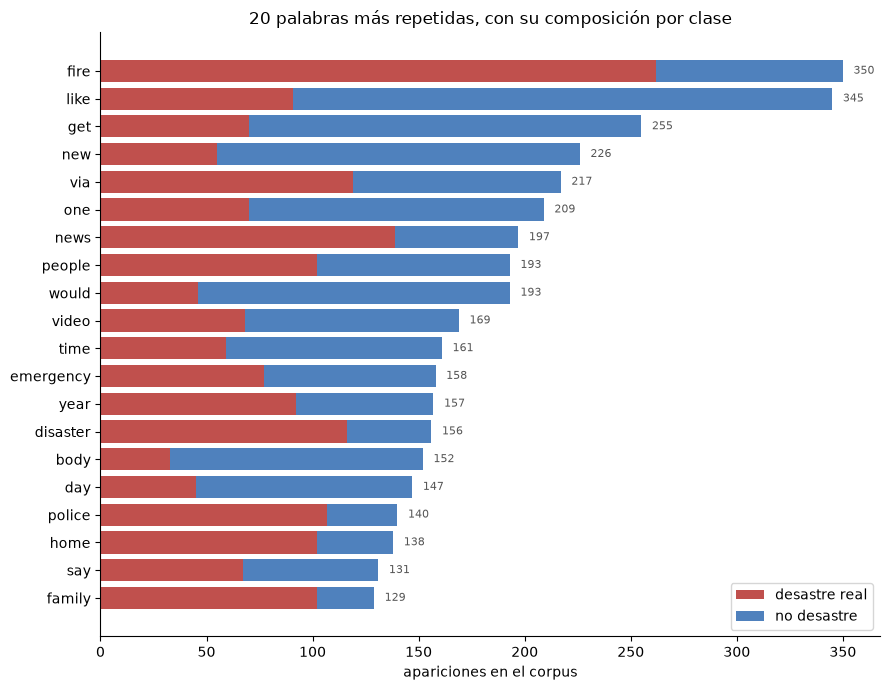

In [5]:
global_top = (conteo["desastre"] + conteo["no_desastre"]).most_common(20)
palabras = [p for p, _ in global_top][::-1]
f_des = [conteo["desastre"][p] for p in palabras]
f_no = [conteo["no_desastre"][p] for p in palabras]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(palabras, f_des, color="#c0504d", label="desastre real")
ax.barh(palabras, f_no, left=f_des, color="#4f81bd", label="no desastre")
for y, (a, b) in enumerate(zip(f_des, f_no)):
    ax.text(a + b + 5, y, f"{a + b}", va="center", fontsize=8, color="#555")
ax.set_xlabel("apariciones en el corpus")
ax.set_title("20 palabras más repetidas, con su composición por clase", fontsize=12)
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

El histograma muestra que casi todas las palabras más repetidas del corpus reciben aportes de las
dos clases, aunque en proporciones muy distintas. Por ejemplo `fire` es mayoritariamente de desastre
con un 75%, mientras que `like`, `get` y `would` vienen sobre todo de la clase contraria.

Dicho esto, el reparto es lo informativo y no la altura de la barra, ya que una palabra muy
frecuente repartida en partes iguales no le sirve al modelo.

## **4. Palabras presentes en las dos categorías**

In [6]:
compartidas = set(conteo["desastre"]) & set(conteo["no_desastre"])
vocabulario = set(conteo["desastre"]) | set(conteo["no_desastre"])
apariciones_totales = sum(conteo["desastre"].values()) + sum(conteo["no_desastre"].values())
apariciones_compartidas = sum(conteo["desastre"][w] + conteo["no_desastre"][w]
                              for w in compartidas)

print(f"vocabulario total                : {len(vocabulario):,} palabras distintas")
print(f"presentes en las DOS categorias  : {len(compartidas):,} "
      f"({len(compartidas) / len(vocabulario) * 100:.1f}% del vocabulario)")
print(f"exclusivas de desastre           : {len(set(conteo['desastre']) - compartidas):,}")
print(f"exclusivas de no desastre        : {len(set(conteo['no_desastre']) - compartidas):,}")
print(f"\nesas compartidas concentran      : {apariciones_compartidas:,} de "
      f"{apariciones_totales:,} apariciones "
      f"({apariciones_compartidas / apariciones_totales * 100:.1f}% del texto)")

total_compartidas = Counter({w: conteo["desastre"][w] + conteo["no_desastre"][w]
                             for w in compartidas})
tabla = pd.DataFrame([
    {"palabra": w, "total": f,
     "desastre": conteo["desastre"][w], "no_desastre": conteo["no_desastre"][w],
     "pct_desastre": round(conteo["desastre"][w] / f * 100, 1)}
    for w, f in total_compartidas.most_common(12)
])
tabla

vocabulario total                : 12,735 palabras distintas
presentes en las DOS categorias  : 3,413 (26.8% del vocabulario)
exclusivas de desastre           : 3,606
exclusivas de no desastre        : 5,716

esas compartidas concentran      : 48,017 de 62,673 apariciones (76.6% del texto)


,palabra,total,desastre,no_desastre,pct_desastre
0,fire,350,262,88,74.9
1,like,345,91,254,26.4
2,get,255,70,185,27.5
3,new,226,55,171,24.3
4,via,217,119,98,54.8
5,one,209,70,139,33.5
6,news,197,139,58,70.6
7,would,193,46,147,23.8
8,people,193,102,91,52.8
9,video,169,68,101,40.2


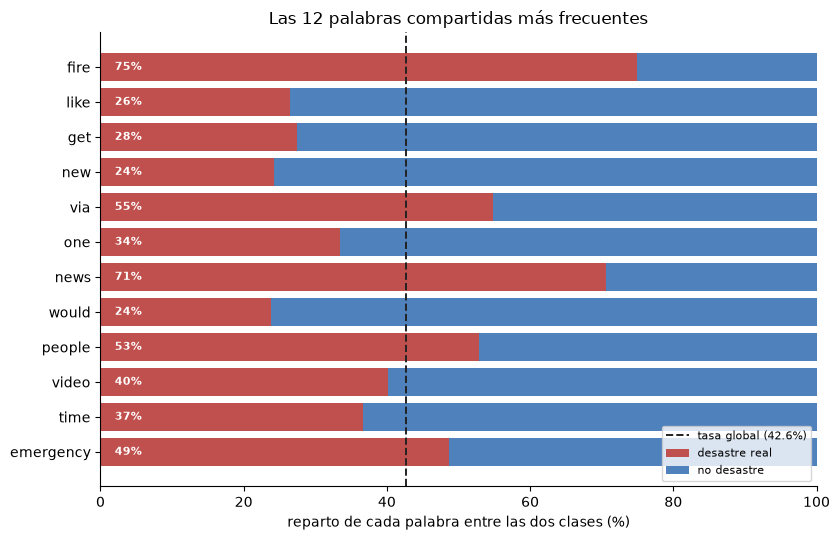

In [7]:
d = tabla.iloc[::-1]
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.barh(d["palabra"], d["pct_desastre"], color="#c0504d", label="desastre real")
ax.barh(d["palabra"], 100 - d["pct_desastre"], left=d["pct_desastre"],
        color="#4f81bd", label="no desastre")
ax.axvline(42.6, color="#222", ls="--", lw=1.4, label="tasa global (42.6%)")
for y, p in enumerate(d["pct_desastre"]):
    ax.text(2, y, f"{p:.0f}%", va="center", fontsize=8, color="white", fontweight="bold")
ax.set_xlim(0, 100)
ax.set_xlabel("reparto de cada palabra entre las dos clases (%)")
ax.set_title("Las 12 palabras compartidas más frecuentes", fontsize=12)
ax.legend(loc="lower right", fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

El dato que más llama la atención es el desbalance entre tipos y volumen:

- Solo el **26.8% del vocabulario** aparece en las dos categorías, sin embargo esas palabras
  concentran el **76.6% de todo el texto**, o sea que son pocas pero son las que más se usan.
- Las verdaderamente ambiguas se reparten cerca de la tasa global del 42.6%, y en el gráfico son
  `via`, `people` y `video`. Esas no le aportan nada al clasificador.
- Otras están compartidas pero muy sesgadas, como `fire` con un 75% del lado de desastre y `would`
  con un 24%, de tal forma que sí discriminan aunque aparezcan en ambos lados.

Dicho esto, la conclusión práctica es que estar presente en las dos categorías no descalifica a una
palabra, ya que lo que importa es el reparto y no la presencia. Es por esto que en el ejercicio 4 se
midió el log-odds en lugar de filtrar las palabras compartidas, y por eso conviene dejar que el
modelo pondere cada término a partir de ese reparto en lugar de armar listas a mano.